# Employment Outcome and Skilling Impact Analysis

This notebook analyzes the PMKVY aggregate training funnel. It measures enrollment, training, assessment, certification, and reported placement outcomes by program and geography. The source is aggregated rather than individual-level, so this pipeline prioritizes transparent impact analytics over an unsupported individual prediction model.

## Data loading and inspection

The schema is checked explicitly. Paths are resolved with `pathlib` so the notebook can run from the project root or its notebook directory.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = next(parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / 'ml' / 'data').exists())
DATA_PATH = PROJECT_ROOT / 'ml' / 'data' / 'PMKVY-210422.csv'
MODEL_DIR = PROJECT_ROOT / 'ml' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists(), DATA_PATH
df = pd.read_csv(DATA_PATH)
print('shape:', df.shape)
print('columns:', df.columns.tolist())
display(df.head())
display(df.sample(min(5, len(df)), random_state=42))
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('missing'))
print('duplicate rows:', int(df.duplicated().sum()))
display(df.describe(include='all').T)

shape: (5138, 11)
columns: ['Data Till', 'Scheme', 'Component', 'TrainingType', 'TCState', 'TCDistrict', 'Enrolled', 'Trained', 'Assessed', 'Certified', 'Reported Placed']


,Data Till,Scheme,Component,TrainingType,TCState,TCDistrict,Enrolled,Trained,Assessed,Certified,Reported Placed
0,21-04-2022,PMKVY 2.0,CSCM,RPL,Andaman And Nicobar Islands,Nicobars,46,46,46,46,0
1,21-04-2022,PMKVY 2.0,CSCM,RPL,Andaman And Nicobar Islands,South Andamans,10,10,6,6,0
2,21-04-2022,PMKVY 2.0,CSCM,STT,Andaman And Nicobar Islands,Nicobars,120,120,120,108,0
3,21-04-2022,PMKVY 2.0,CSSM,STT,Andaman And Nicobar Islands,Nicobars,156,156,78,57,0
4,21-04-2022,PMKVY 2.0,CSCM,STT,Andaman And Nicobar Islands,North And Middle Andaman,1041,870,861,839,124


,Data Till,Scheme,Component,TrainingType,TCState,TCDistrict,Enrolled,Trained,Assessed,Certified,Reported Placed
838,21-04-2022,PMKVY 3.0,CSCM,RPL,Chhattisgarh,Durg,120,120,93,93,0
977,21-04-2022,PMKVY 3.0,CSCM,SP,Delhi,South West,745,728,684,126,0
3985,21-04-2022,PMKVY 3.0,CSSM,STT,Tamil Nadu,Coimbatore,180,132,104,97,26
798,21-04-2022,PMKVY 2.0,CSSM,STT,Chhattisgarh,Gariyaband,517,517,428,307,148
2042,21-04-2022,PMKVY 3.0,CSSM,STT,Karnataka,Tumakuru,60,60,60,53,0


,dtype
Data Till,object
Scheme,object
Component,object
TrainingType,object
TCState,object
TCDistrict,object
Enrolled,int64
Trained,int64
Assessed,int64
Certified,int64


,missing
Data Till,0
Scheme,0
Component,0
TrainingType,0
TCState,0
TCDistrict,0
Enrolled,0
Trained,0
Assessed,0
Certified,0


duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Data Till,5138,1,21-04-2022,5138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scheme,5138,2,PMKVY 3.0,2699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Component,5138,2,CSCM,3414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrainingType,5138,3,STT,2516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCState,5138,36,Uttar Pradesh,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCDistrict,5138,720,Aurangabad,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Enrolled,5138.0,NaN,NaN,NaN,2386.846049,6918.405597,0.0,132.25,374.5,1710.75,171252.0
Trained,5138.0,NaN,NaN,NaN,2247.815492,6760.469504,0.0,120.0,259.0,1568.75,168349.0
Assessed,5138.0,NaN,NaN,NaN,2009.13624,6111.68478,0.0,85.25,198.0,1379.25,155000.0
Certified,5138.0,NaN,NaN,NaN,1829.335928,5800.133446,0.0,50.0,151.0,1222.0,148641.0


## Cleaning and data-quality checks

The dataset contains one reporting date, so time-series forecasting is not supported. Counts are converted explicitly and impossible relationships are flagged rather than silently removed. Descriptive totals preserve every source row, including duplicate natural keys and anomalous rows. Funnel rates use stage-valid rows only: an invalid relationship excludes that row from the affected stage and downstream rates, while the row remains visible in the separate anomaly report.

In [ ]:
measure_columns = ['Enrolled', 'Trained', 'Assessed', 'Certified', 'Reported Placed']
dimension_columns = ['Data Till', 'Scheme', 'Component', 'TrainingType', 'TCState', 'TCDistrict']
required_columns = dimension_columns + measure_columns
missing_columns = sorted(set(required_columns) - set(df.columns))
assert not missing_columns, missing_columns
for column in measure_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df['Data Till'] = pd.to_datetime(df['Data Till'], dayfirst=True, errors='coerce')
invalid_numeric = df[measure_columns].isna().any(axis=1)
negative_measure = (df[measure_columns] < 0).any(axis=1)
natural_key = dimension_columns
duplicate_key = df.duplicated(natural_key, keep='first')
trained_gt_enrolled = df['Trained'].gt(df['Enrolled'])
assessed_gt_trained = df['Assessed'].gt(df['Trained'])
certified_gt_assessed = df['Certified'].gt(df['Assessed'])
placed_gt_certified = df['Reported Placed'].gt(df['Certified'])
df['quality_flag'] = invalid_numeric | negative_measure | trained_gt_enrolled | assessed_gt_trained | certified_gt_assessed | placed_gt_certified
df['anomaly_reasons'] = [
    '; '.join(reason for reason, condition in [
        ('invalid_numeric', invalid_numeric.iloc[index]),
        ('negative_measure', negative_measure.iloc[index]),
        ('trained_gt_enrolled', trained_gt_enrolled.iloc[index]),
        ('assessed_gt_trained', assessed_gt_trained.iloc[index]),
        ('certified_gt_assessed', certified_gt_assessed.iloc[index]),
        ('placed_gt_certified', placed_gt_certified.iloc[index]),
    ] if condition)
    for index in range(len(df))
]
anomaly_report = df.loc[df['quality_flag'], dimension_columns + measure_columns + ['anomaly_reasons']].copy()
quality_summary = {
    'invalid_numeric_rows': int(invalid_numeric.sum()),
    'duplicate_natural_keys': int(duplicate_key.sum()),
    'negative_measure_rows': int(negative_measure.sum()),
    'trained_gt_enrolled': int(trained_gt_enrolled.sum()),
    'assessed_gt_trained': int(assessed_gt_trained.sum()),
    'certified_gt_assessed': int(certified_gt_assessed.sum()),
    'placed_gt_certified': int(placed_gt_certified.sum()),
}
print(json.dumps(quality_summary, indent=2))
print('flagged rows:', int(df['quality_flag'].sum()))
display(anomaly_report.head())

{
  "invalid_numeric_rows": 0,
  "duplicate_natural_keys": 1,
  "negative_measure_rows": 0,
  "trained_gt_enrolled": 0,
  "assessed_gt_trained": 1,
  "certified_gt_assessed": 0,
  "placed_gt_certified": 36
}
flagged rows: 37


In [ ]:
# Preserve descriptive counts while using stage-valid rows for funnel rates.
analysis_df = df.groupby(natural_key, as_index=False, dropna=False)[measure_columns].sum()
base_valid = ~(invalid_numeric | negative_measure)
stage_valid = {
    'training': base_valid & ~trained_gt_enrolled,
    'assessment': base_valid & ~trained_gt_enrolled & ~assessed_gt_trained,
    'certification': base_valid & ~trained_gt_enrolled & ~assessed_gt_trained & ~certified_gt_assessed,
    'placement': base_valid & ~trained_gt_enrolled & ~assessed_gt_trained & ~certified_gt_assessed & ~placed_gt_certified,
}
for stage, mask in stage_valid.items():
    numerator, denominator = {
        'training': ('Trained', 'Enrolled'),
        'assessment': ('Assessed', 'Trained'),
        'certification': ('Certified', 'Assessed'),
        'placement': ('Reported Placed', 'Certified'),
    }[stage]
    grouped_numerator = df[numerator].where(mask, 0).groupby([df[column] for column in natural_key], dropna=False).sum()
    grouped_denominator = df[denominator].where(mask, 0).groupby([df[column] for column in natural_key], dropna=False).sum()
    analysis_df[f'{stage}_numerator'] = grouped_numerator.to_numpy()
    analysis_df[f'{stage}_denominator'] = grouped_denominator.to_numpy()

def safe_rate(numerator, denominator):
    values = np.divide(numerator, denominator, out=np.full(len(numerator), np.nan, dtype=float), where=denominator.ne(0))
    return pd.Series(np.clip(values, 0.0, 1.0), index=numerator.index)

analysis_df['training_completion_rate'] = safe_rate(analysis_df['training_numerator'], analysis_df['training_denominator'])
analysis_df['assessment_rate'] = safe_rate(analysis_df['assessment_numerator'], analysis_df['assessment_denominator'])
analysis_df['certification_rate'] = safe_rate(analysis_df['certification_numerator'], analysis_df['certification_denominator'])
analysis_df['placement_rate'] = safe_rate(analysis_df['placement_numerator'], analysis_df['placement_denominator'])
analysis_df['pipeline_dropoff_rate'] = (1 - safe_rate(analysis_df['placement_numerator'], analysis_df['training_denominator'])).clip(0.0, 1.0)
analysis_df['program_effectiveness_score'] = (
    analysis_df['training_completion_rate'].fillna(0) * analysis_df['assessment_rate'].fillna(0) *
    analysis_df['certification_rate'].fillna(0) * analysis_df['placement_rate'].fillna(0)
)
rate_columns = ['training_completion_rate', 'assessment_rate', 'certification_rate', 'placement_rate', 'pipeline_dropoff_rate']
assert analysis_df[rate_columns].stack().dropna().between(0, 1).all()
display(analysis_df[measure_columns + rate_columns].describe().T)
display(analysis_df.sort_values('Reported Placed', ascending=False).head(10))

,count,mean,std,min,25%,50%,75%,max
Enrolled,5137.0,2387.310687,6918.999018,0.0,133.000000,375.000000,1711.000000,171252.000000
Trained,5137.0,2248.253066,6761.054850,0.0,120.000000,259.000000,1569.000000,168349.000000
Assessed,5137.0,2009.527351,6112.215431,0.0,86.000000,198.000000,1380.000000,155000.000000
Certified,5137.0,1829.692038,5800.641899,0.0,50.000000,151.000000,1223.000000,148641.000000
Reported Placed,5137.0,418.288690,1397.390049,0.0,0.000000,0.000000,80.000000,21682.000000
training_completion_rate,5137.0,0.874122,0.239268,0.0,0.896664,0.991250,1.000000,1.000000
assessment_rate,5137.0,0.767937,0.278528,0.0,0.709524,0.878378,0.953846,1.160763
certification_rate,5137.0,0.726980,0.333387,0.0,0.712803,0.878390,0.933333,1.000000
placement_rate,5137.0,0.183728,0.301131,0.0,0.000000,0.000000,0.382979,7.250000
pipeline_dropoff_rate,5137.0,0.880040,0.203588,0.0,0.813559,1.000000,1.000000,1.000000


,Data Till,Scheme,Component,TrainingType,TCState,TCDistrict,Enrolled,Trained,Assessed,Certified,Reported Placed,training_completion_rate,assessment_rate,certification_rate,placement_rate,pipeline_dropoff_rate,program_effectiveness_score
1578,2022-04-21,PMKVY 2.0,CSCM,STT,Rajasthan,Jaipur,43222,41513,39774,36597,21682,0.960460,0.958110,0.920124,0.592453,0.498357,0.501643
1582,2022-04-21,PMKVY 2.0,CSCM,STT,Rajasthan,Jhunjhunu,43216,41635,40667,38250,21029,0.963416,0.976750,0.940566,0.549778,0.513398,0.486602
1646,2022-04-21,PMKVY 2.0,CSCM,STT,Telangana,Nalgonda,29991,28256,27571,25644,18539,0.942149,0.975757,0.930108,0.722937,0.381848,0.618152
1261,2022-04-21,PMKVY 2.0,CSCM,STT,Haryana,Hisar,27800,26919,25788,24121,16849,0.968309,0.957985,0.935358,0.698520,0.393921,0.606079
1256,2022-04-21,PMKVY 2.0,CSCM,STT,Haryana,Bhiwani,26802,25536,24635,22419,16437,0.952765,0.964716,0.910047,0.733173,0.386725,0.613275
1716,2022-04-21,PMKVY 2.0,CSCM,STT,Uttar Pradesh,Lucknow,33878,30023,28258,25825,14351,0.886209,0.941212,0.913900,0.555702,0.576392,0.423608
1651,2022-04-21,PMKVY 2.0,CSCM,STT,Telangana,Ranga Reddy,24243,22919,22088,20542,14292,0.945386,0.963742,0.930007,0.695745,0.410469,0.589531
1577,2022-04-21,PMKVY 2.0,CSCM,STT,Rajasthan,Hanumangarh,26957,25872,25405,23870,13026,0.959751,0.981950,0.939579,0.545706,0.516786,0.483214
1219,2022-04-21,PMKVY 2.0,CSCM,STT,Delhi,West,28909,26437,24538,22486,13003,0.914490,0.928169,0.916375,0.578271,0.550209,0.449791
1214,2022-04-21,PMKVY 2.0,CSCM,STT,Delhi,North West,29868,27683,26370,24540,12916,0.926845,0.952570,0.930603,0.526324,0.567564,0.432436


## Performance views

These views compare groups only where the relevant denominator exists. They are descriptive and should not be interpreted as causal estimates.


 ['Scheme']


,Scheme,Enrolled,Trained,Assessed,Certified,Reported Placed,training_completion_rate,assessment_rate,certification_rate,placement_rate,pipeline_dropoff_rate
0,PMKVY 2.0,11484466,10999560,9916853,9127363,2123648,0.957777,0.901568,0.920389,0.232668,0.815085
1,PMKVY 3.0,779149,549716,406089,271765,25101,0.705534,0.738725,0.669225,0.092363,0.967784



 ['Component']


,Component,Enrolled,Trained,Assessed,Certified,Reported Placed,training_completion_rate,assessment_rate,certification_rate,placement_rate,pipeline_dropoff_rate
0,CSCM,11229958,10563338,9478437,8658337,1921064,0.940639,0.897296,0.913477,0.221874,0.828934
1,CSSM,1033657,985938,844505,740791,227685,0.953835,0.856550,0.877190,0.307354,0.779729



 ['TrainingType']


,TrainingType,Enrolled,Trained,Assessed,Certified,Reported Placed,training_completion_rate,assessment_rate,certification_rate,placement_rate,pipeline_dropoff_rate
2,STT,5367355,4815636,4441819,3954589,2062265,0.897208,0.922374,0.890308,0.521487,0.615776
1,SP,358821,330367,284148,168403,86484,0.920701,0.860098,0.592659,0.513554,0.758977
0,RPL,6537439,6403273,5596975,5276136,0,0.979477,0.874080,0.942676,0.000000,1.000000



 ['TCState']


,TCState,Enrolled,Trained,Assessed,Certified,Reported Placed,training_completion_rate,assessment_rate,certification_rate,placement_rate,pipeline_dropoff_rate
33,Uttar Pradesh,1745251,1652147,1500911,1364356,310225,0.946653,0.908461,0.909019,0.227378,0.822246
18,Madhya Pradesh,771281,719105,654479,575383,195162,0.932352,0.910130,0.879147,0.339186,0.746964
27,Rajasthan,988591,951808,896885,843170,170079,0.962792,0.942296,0.940109,0.201714,0.827958
10,Haryana,591908,556275,504889,466103,150544,0.939800,0.907625,0.923179,0.322984,0.745663
29,Tamil Nadu,618283,585204,522931,483240,126340,0.946499,0.893588,0.924099,0.261444,0.795660
26,Punjab,369589,343443,314600,286008,117540,0.929257,0.916018,0.909116,0.410968,0.681971
4,Bihar,566635,530060,483380,423286,113067,0.935452,0.911934,0.875680,0.267117,0.800459
35,West Bengal,475618,446635,400752,365828,100715,0.939062,0.897270,0.912854,0.275307,0.788244
1,Andhra Pradesh,340821,315744,287846,266184,92704,0.926422,0.911644,0.924744,0.348270,0.727998
30,Telangana,333214,306544,278562,255445,91674,0.919961,0.908718,0.917013,0.358880,0.724880


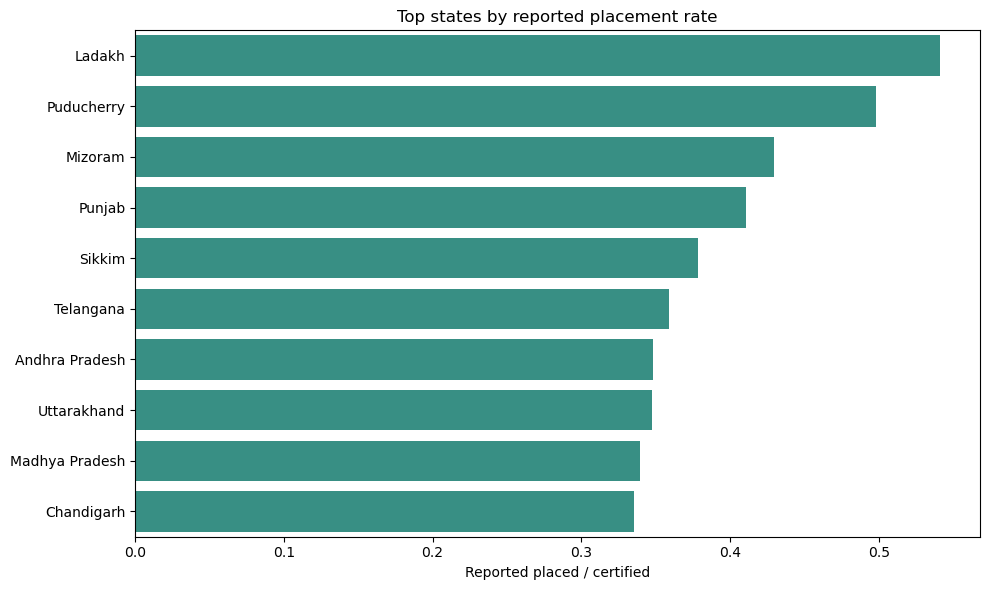

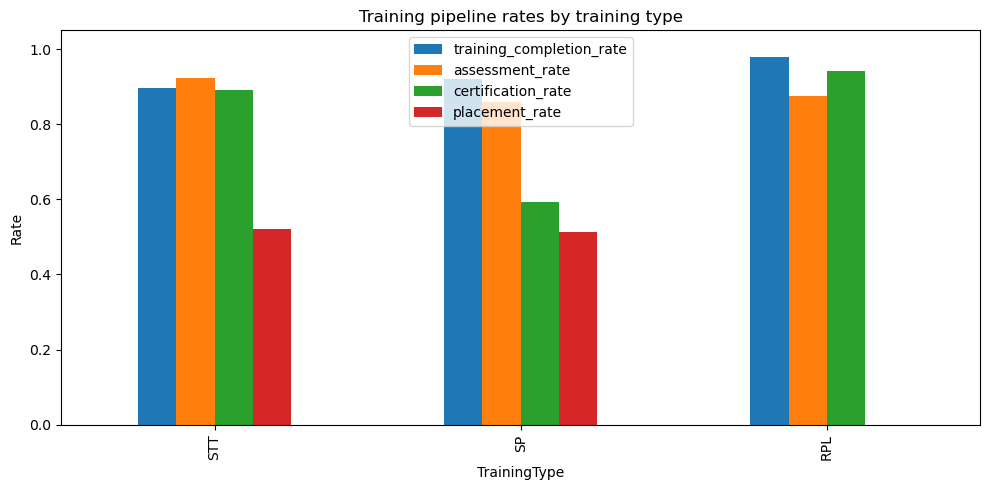

In [ ]:
def grouped_performance(group_columns):
    grouped = analysis_df.groupby(group_columns, as_index=False)[measure_columns + [
        'training_numerator', 'training_denominator', 'assessment_numerator', 'assessment_denominator',
        'certification_numerator', 'certification_denominator', 'placement_numerator', 'placement_denominator'
    ]].sum()
    grouped['training_completion_rate'] = safe_rate(grouped['training_numerator'], grouped['training_denominator'])
    grouped['assessment_rate'] = safe_rate(grouped['assessment_numerator'], grouped['assessment_denominator'])
    grouped['certification_rate'] = safe_rate(grouped['certification_numerator'], grouped['certification_denominator'])
    grouped['placement_rate'] = safe_rate(grouped['placement_numerator'], grouped['placement_denominator'])
    grouped['pipeline_dropoff_rate'] = (1 - safe_rate(grouped['placement_numerator'], grouped['training_denominator'])).clip(0.0, 1.0)
    assert grouped[rate_columns].stack().dropna().between(0, 1).all()
    return grouped

for grouping in [['Scheme'], ['Component'], ['TrainingType'], ['TCState']]:
    view = grouped_performance(grouping).sort_values('Reported Placed', ascending=False)
    print('\n', grouping)
    display(view.head(15))

state_view = grouped_performance(['TCState']).sort_values('placement_rate', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=state_view.head(10), y='TCState', x='placement_rate', color='#2a9d8f')
plt.title('Top states by valid reported placement rate')
plt.xlabel('Valid reported placed / valid certified')
plt.ylabel('')
plt.tight_layout()
plt.show()

training_view = grouped_performance(['TrainingType']).sort_values('Reported Placed', ascending=False)
training_view.set_index('TrainingType')[['training_completion_rate', 'assessment_rate', 'certification_rate', 'placement_rate']].plot(kind='bar', figsize=(10, 5))
plt.ylim(0, 1.05)
plt.title('Valid training pipeline rates by training type')
plt.ylabel('Rate')
plt.tight_layout()
plt.show()

## Reusable employment artifact

Because the source has one date and aggregate rows, the saved artifact is an analytics configuration and summary rather than a fabricated predictive model. It contains the schema, funnel definitions, quality findings, and grouped summaries needed by a future engine.

In [ ]:
artifact = {
    'artifact_type': 'pmkvy_employment_analytics',
    'version': 2,
    'source_file': DATA_PATH.name,
    'row_count': int(len(df)),
    'analysis_row_count': int(len(analysis_df)),
    'columns': required_columns,
    'natural_key': natural_key,
    'measure_columns': measure_columns,
    'quality_summary': quality_summary,
    'anomaly_report': anomaly_report.to_dict('records'),
    'descriptive_totals': df[measure_columns].sum().to_dict(),
    'rate_policy': {
        'descriptive_counts': 'Preserve all source rows, including duplicate natural keys and anomalies.',
        'invalid_relationships': 'Exclude a row from the affected stage and all downstream stage rates; retain it in anomaly_report.',
        'zero_denominator': 'Report rate as NaN/not applicable.',
        'bounds': '[0, 1] after valid-row filtering and clipping.',
    },
    'metric_definitions': {
        'training_completion_rate': 'Valid Trained / valid Enrolled when Enrolled > 0',
        'assessment_rate': 'Valid Assessed / valid Trained when Trained > 0',
        'certification_rate': 'Valid Certified / valid Assessed when Assessed > 0',
        'placement_rate': 'Valid Reported Placed / valid Certified when Certified > 0',
        'pipeline_dropoff_rate': '1 - valid Reported Placed / valid Trained when valid Trained > 0',
        'program_effectiveness_score': 'Product of the four bounded stage rates, with unavailable rates treated as zero for the score.',
    },
    'grouped_summaries': {
        'scheme': grouped_performance(['Scheme']).to_dict('records'),
        'component': grouped_performance(['Component']).to_dict('records'),
        'training_type': grouped_performance(['TrainingType']).to_dict('records'),
        'state': grouped_performance(['TCState']).to_dict('records'),
    },
    'modeling_decision': 'analytics_only: one reporting date and aggregate program/geography grain',
}
artifact_path = MODEL_DIR / 'employment_model.joblib'
joblib.dump(artifact, artifact_path)
assert artifact_path.exists() and artifact_path.stat().st_size > 0
loaded_artifact = joblib.load(artifact_path)
assert loaded_artifact['artifact_type'] == 'pmkvy_employment_analytics'
assert loaded_artifact['quality_summary'] == quality_summary
assert loaded_artifact['anomaly_report']
print('saved:', artifact_path)
print('artifact keys:', sorted(loaded_artifact))

saved: o:\Ps135\Ps135\ml\models\employment_model.joblib
artifact keys: ['analysis_row_count', 'artifact_type', 'columns', 'grouped_summaries', 'measure_columns', 'metric_definitions', 'modeling_decision', 'natural_key', 'quality_summary', 'row_count', 'source_file', 'version']
